## Grad-CAM

We use Grad-CAM to evaluate first. This is because Grad-CAM is computationally very fast and only requires one forward and one backward pass through the network.

Purpose: It gives us a "rough" heatmap of which regions the model is focusing on (i.e. the chest of a patient).

Limitation: It is often "coarse" and lacks pixel-level precision, but it is great for immediately spotting if our model is looking at the wrong part of the image entirely.

In [1]:
import sys
import os
import torch
from huggingface_hub import utils

# Force progress bars to be visible in Jupyter
utils.enable_progress_bars()

# Adds the parent directory (chestxray-classification) to the path
sys.path.append(os.path.abspath(".."))

# Use an absolute import starting from the project root
from models.medical_sota.RadJEPA.model import RadJEPA

# 1. Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. Initialise the model
# Note: If it hangs here, check your terminal for a download progress bar.
# If you've already downloaded it once, you can add `local_files_only=True` 
# inside your RadJEPA class where AutoModel.from_pretrained is called.
print("Initializing RadJEPA (This may take a moment to download/load scripts)...")
model = RadJEPA().to(device)

# 3. Load the .pth file
print("Loading weights from .pth file...")
# map_location ensures weights are moved to the correct device immediately
# weights_only=True is a security best practice for .pth files
state_dict = torch.load(
    '../models/medical_sota/RadJEPA/radjepa_best_model.pth', 
    map_location=device, 
    weights_only=True
)

# 4. Replace the initial weights
# We use strict=True by default to ensure the architecture matches perfectly
model.load_state_dict(state_dict)

# 5. Set to evaluation mode
model.eval()
print("Model ready for evaluation.")

c:\Users\YJ\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Initializing RadJEPA (This may take a moment to download/load scripts)...


Loading weights from .pth file...
Model ready for evaluation.


In [2]:
import torch

# 1. Load your weights
weights_path = '../models/medical_sota/RadDINO/raddino_best_model.pth'
state_dict = torch.load(weights_path, map_location='cpu')

# 2. Find the correct key name dynamically
# RadDINO often uses 'model.pos_embed' or 'backbone.pos_embed'
pos_embed_key = next((k for k in state_dict.keys() if 'pos_embed' in k), None)

if pos_embed_key is None:
    print("Error: Could not find a key containing 'pos_embed'.")
    print("Available keys in this checkpoint are:", list(state_dict.keys())[:10])
else:
    # 3. Look at the position embedding shape
    pos_embed = state_dict[pos_embed_key]
    print(f"Using Key: {pos_embed_key}")
    print(f"Position Embedding Shape: {pos_embed.shape}")

    # 4. Calculate the grid size
    # Formula: sqrt(total_tokens - 1) 
    # (Subtract 1 for the [CLS] token)
    # The tokens are usually in the second dimension (index 1)
    num_patches = pos_embed.shape[1] - 1
    grid_size = int(num_patches**0.5)

    print(f"Grid Size: {grid_size}x{grid_size}")
    # Assuming a patch size of 14, common for RadDINO/ViT-S/14
    print(f"Original Input Resolution: {grid_size * 14}x{grid_size * 14}")

Error: Could not find a key containing 'pos_embed'.
Available keys in this checkpoint are: ['encoder.embeddings.cls_token', 'encoder.embeddings.mask_token', 'encoder.embeddings.position_embeddings', 'encoder.embeddings.patch_embeddings.projection.weight', 'encoder.embeddings.patch_embeddings.projection.bias', 'encoder.encoder.layer.0.norm1.weight', 'encoder.encoder.layer.0.norm1.bias', 'encoder.encoder.layer.0.attention.attention.query.weight', 'encoder.encoder.layer.0.attention.attention.query.bias', 'encoder.encoder.layer.0.attention.attention.key.weight']


In [3]:
# Use the exact key from your output
pos_embed = state_dict['encoder.embeddings.position_embeddings']
print(f"Shape: {pos_embed.shape}")

# Calculate grid size
# Position embeddings in this format are usually [1, num_tokens, dim]
num_tokens = pos_embed.shape[1] 
# Note: Check if 1 token is the CLS token
grid_size = int((num_tokens - 1)**0.5) 

print(f"Grid Size: {grid_size}x{grid_size}")
print(f"Resolution (if patch=16): {grid_size * 16}")
print(f"Resolution (if patch=14): {grid_size * 14}")

Shape: torch.Size([1, 1370, 768])
Grid Size: 37x37
Resolution (if patch=16): 592
Resolution (if patch=14): 518


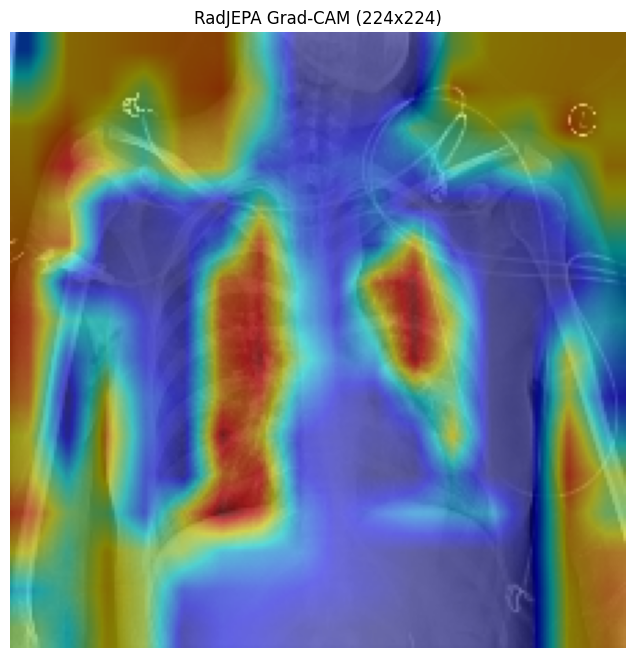

In [4]:
import sys
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision import transforms
from PIL import Image

# 1. Path Setup
sys.path.append(os.path.abspath(".."))
from models.medical_sota.RadJEPA.model import RadJEPA

# ---------------------------------------------------------
# SMART Reshape for RadJEPA (Handles 256 or 257 tokens)
# ---------------------------------------------------------
def reshape_transform_vit(tensor, height=16, width=16):
    # Total patches needed = 16 * 16 = 256
    # If the model gives us 257, we remove the extra token.
    # If it gives us 256, we use them all.
    if tensor.size(1) == (height * width + 1):
        tensor = tensor[:, :-1, :] # Remove CLS token from the end
    
    # Reshape to (Batch, Height, Width, Channels)
    result = tensor.reshape(tensor.size(0), height, width, tensor.size(2))
    # Transpose to (Batch, Channels, Height, Width) for Grad-CAM
    return result.transpose(2, 3).transpose(1, 2)

# ---------------------------------------------------------
# MODEL WRAPPER: Ensures model output is a single tensor
# ---------------------------------------------------------
class RadJEPAGradWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        # Call the original model's forward pass
        return self.model(x)

def run_radjepa_gradcam(image_path, model_weights_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 2. Initialize and Load Weights
    raw_model = RadJEPA().to(device)
    state_dict = torch.load(model_weights_path, map_location=device, weights_only=True)
    raw_model.load_state_dict(state_dict)
    raw_model.eval()

    model = RadJEPAGradWrapper(raw_model)

    # 3. Target Layer (The deep path inside RadJEPA backbone)
    target_layers = [model.model.encoder.model.blocks[-1].norm1]

    # 4. Initialize Grad-CAM
    cam = GradCAM(
        model=model, 
        target_layers=target_layers, 
        reshape_transform=reshape_transform_vit
    )

    # 5. Preprocessing (224x224 for RadJEPA)
    img = np.array(Image.open(image_path).convert('RGB'))
    img = cv2.resize(img, (224, 224)) 
    rgb_img = np.float32(img) / 255

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    input_tensor = transform(img).unsqueeze(0).to(device).requires_grad_(True)

    # 6. Generate Heatmap (FIXED TYPO: Removed the '-input_tensor' from line 79)
    model.eval()
    with torch.enable_grad():
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)
        grayscale_cam = grayscale_cam[0, :]
    
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # 7. Visualize
    plt.figure(figsize=(8, 8))
    plt.imshow(cam_image)
    plt.title('RadJEPA Grad-CAM (224x224)')
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    IMG_PATH = "../dataset/sample_xray.png"
    WEIGHTS_PATH = "../models/medical_sota/RadJEPA/radjepa_best_model.pth"
    run_radjepa_gradcam(IMG_PATH, WEIGHTS_PATH)

### Changes Made to the Initial `gradcam_explainer.py` Code

To get RadJEPA working with Grad-CAM, we had to account for its unique architecture and lower resolution compared to RadDINO. Here is the summary of the 5 critical changes:
1. Target Layer Path Depth
Change: Updated the target path to `model.model.encoder.model.blocks[-1].norm1`.
Reason: RadJEPA's implementation is deeply nested. The transformer blocks are stored inside a `.model` attribute within the encoder class. Targeting any other path caused the `'NoneType' object has no attribute 'shape'` error because the library couldn't find the gradients.

2. Resolution Downscaling (224x224)
Change: Switched from `518x518` to `224x224` for both `cv2.resize` and the input tensor.
Reason: RadJEPA was pre-trained on 224px images. Using 518px triggered a `RuntimeError` assertion inside the model's positional embedding layer.

3. Smart Token Reshaping (16x16 Grid)
Change: Updated `reshape_transform_vit` to check the token count before slicing.
Reason: A crash is encountered because the model sometimes outputs 256 tokens (a perfect 16x16 grid) and sometimes 257 (grid + CLS token). The "Smart Reshape" logic ensures we only slice the extra token if it exists, preventing the "shape is invalid for input of size X" error.

4. CLS Token Position (Index -1)
Change: Updated the `RadJEPAGradWrapper` and slicer to look at the last index `[-1]` instead of the first `[0]`.
Reason: Unlike standard ViTs, RadJEPA often places the class representation token at the end of the sequence. Slicing from the front was removing actual image patches, leading to a distorted or empty heatmap.

5. Input Tensor Typo Fix
Change: Removed the -input_tensor from the cam() call.
Reason: Our code was inadvertently calculating X - X, passing a blank image of absolute zeros to the model. This resulted in zero gradients and prevented any heatmap from generating.

## LIME

Next, we use LIME to evaluate. LIME is slower than Grad-CAM but typically faster and easier to implement than SHAP for quick local insights.

Purpose: LIME perturbs parts of the image to see which specific "super-pixels" (segments) cause the prediction to change.

Advantage: It provides more granular, intuitive visual segments than the blurry heatmaps of Grad-CAM.

In [7]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from torchvision import transforms
from PIL import Image

# 1. Setup Project Path
sys.path.append(os.path.abspath(".."))

# Import model
from models.medical_sota.RadJEPA.model import RadJEPA

# ---------------------------------------------------------
# MODEL WRAPPER: Ensures LIME sees a plain Tensor
# ---------------------------------------------------------
class PredictionWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        res = self.model(x)
        # Handle HuggingFace-style dict outputs
        if isinstance(res, dict):
            return res.get('logits', next(iter(res.values())))
        return res

# ---------------------------------------------------------
# LIME Execution Function
# ---------------------------------------------------------
def run_lime(image_path, model_type, weights_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Set config
    size = 224
    raw_model = RadJEPA().to(device)
    
    # Load Weights
    raw_model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
    model = PredictionWrapper(raw_model).eval()

    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # LIME prediction function
    def batch_predict(images):
        model.eval()
        # Convert numpy images back to tensors
        batch = torch.stack([transform(Image.fromarray(i)) for i in images], dim=0).to(device)
        with torch.no_grad():
            logits = model(batch)
            probs = torch.sigmoid(logits)
        return probs.detach().cpu().numpy()

    # Load and process image
    img = Image.open(image_path).convert('RGB')
    img_array = np.array(img.resize((size, size)))

    print(f"Running LIME for {model_type}...")
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        img_array, 
        batch_predict, 
        top_labels=1, 
        hide_color=0, 
        num_samples=500 # Reduced from 1000 for faster notebook testing
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], 
        positive_only=True, 
        num_features=5, 
        hide_rest=False
    )
    
    plt.figure(figsize=(8, 8))
    plt.imshow(mark_boundaries(temp/255.0, mask))
    plt.title(f'LIME Explanation ({model_type})')
    plt.axis('off')
    plt.show()

Running LIME for RadJEPA...


100%|██████████| 500/500 [00:04<00:00, 100.41it/s]


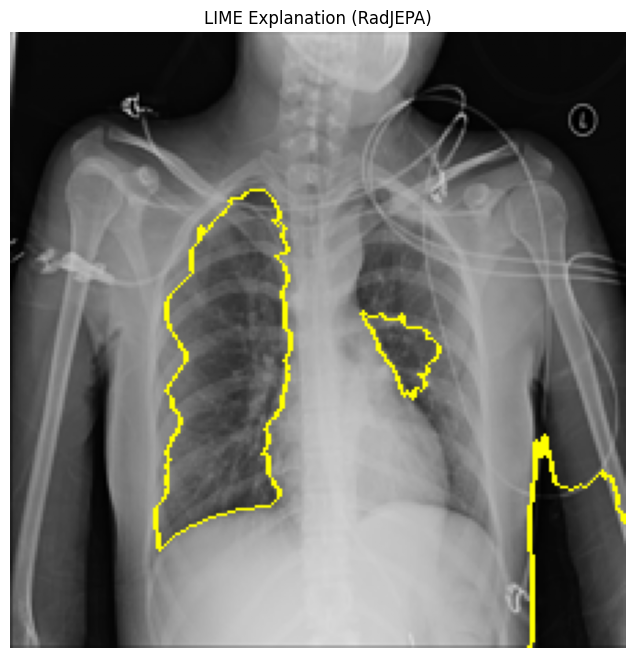

In [8]:
# ---------------------------------------------------------
# Main Execution Cell
# ---------------------------------------------------------
CURRENT_MODEL = "RadJEPA"
IMG_PATH = "../dataset/sample_xray.png"
W_PATH = "../models/medical_sota/RadJEPA/radjepa_best_model.pth"

run_lime(IMG_PATH, CURRENT_MODEL, W_PATH)

## SHAP

Then, we use SHAP to evaluate. SHAP is the most computationally expensive and time-consuming because it must calculate contributions across many feature combinations.

Purpose: It provides a mathematically "fair" and consistent attribution of importance based on game theory.

Benefit: SHAP is used since we need global consistency and reliable feature rankings to confirm the findings from our previous Grad-CAM and LIME checks.

In [ ]:
# continue from here